In [62]:
import tensorflow as tf
from keras.datasets import cifar10
from keras import models, layers 

In [63]:
import tarfile
file = r"cifar-10-python.tar.gz"
with tarfile.open(file, "r:gz") as tar:
    tar.extractall(r"")

In [64]:
import pickle
import numpy as np

path = r"cifar-10-batches-py"

with open(path + r"\data_batch_1", "rb") as f:
    batch = pickle.load(f, encoding="bytes")

print(batch.keys())
print(batch[b"data"].shape)
print(len(batch[b"labels"]))

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
(10000, 3072)
10000


In [65]:
import pickle
import numpy as np

path = r"cifar-10-batches-py"

x_train = []
y_train = []

for i in range(1, 6):

    with open(path + f"\\data_batch_{i}", "rb") as f:
        batch = pickle.load(f, encoding="bytes")

    x_train.append(batch[b"data"])
    y_train.extend(batch[b"labels"])

x_train = np.concatenate(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(50000, 3072)
(50000,)


In [66]:
with open(path + r"\test_batch", "rb") as f:
    batch = pickle.load(f, encoding="bytes")

x_test = batch[b"data"]
y_test = np.array(batch[b"labels"])

print(x_test.shape)
print(y_test.shape)

(10000, 3072)
(10000,)


In [67]:
x_train = x_train.reshape(-1, 3, 32, 32)
x_test = x_test.reshape(-1, 3, 32, 32)

x_train = x_train.transpose(0, 2, 3, 1)
x_test = x_test.transpose(0, 2, 3, 1)

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [68]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
scaler = StandardScaler()
scaler.fit(x_train.reshape(-1, 3 * 32 * 32))
scaler.transform(x_train.reshape(-1, 3 * 32 * 32))
scaler.transform(x_test.reshape(-1, 3 * 32 * 32))

array([[ 0.37172681, -0.32995538, -1.03859408, ..., -1.62707815,
        -0.93937045, -0.06631459],
       [ 1.42059966,  1.3571196 ,  1.27343122, ...,  0.91429096,
         1.18357999,  1.2806016 ],
       [ 0.37172681,  0.73989705,  1.11183805, ..., -1.84270946,
        -1.88113043, -1.62510523],
       ...,
       [-1.5080713 , -1.66041289, -1.49851309, ..., -1.5654692 ,
        -1.68958602, -1.01974964],
       [-1.43996267, -1.31751147, -1.49851309, ..., -0.53351932,
        -0.09338268, -0.52033128],
       [-0.78611985, -0.79630131, -0.71540775, ..., -1.53466472,
        -1.59381382, -1.33756133]])

In [72]:
with open(path + r"\batches.meta", "rb") as f:
    meta = pickle.load(f, encoding="bytes")

classes = [name.decode("utf-8") for name in meta[b"label_names"]]

print(classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


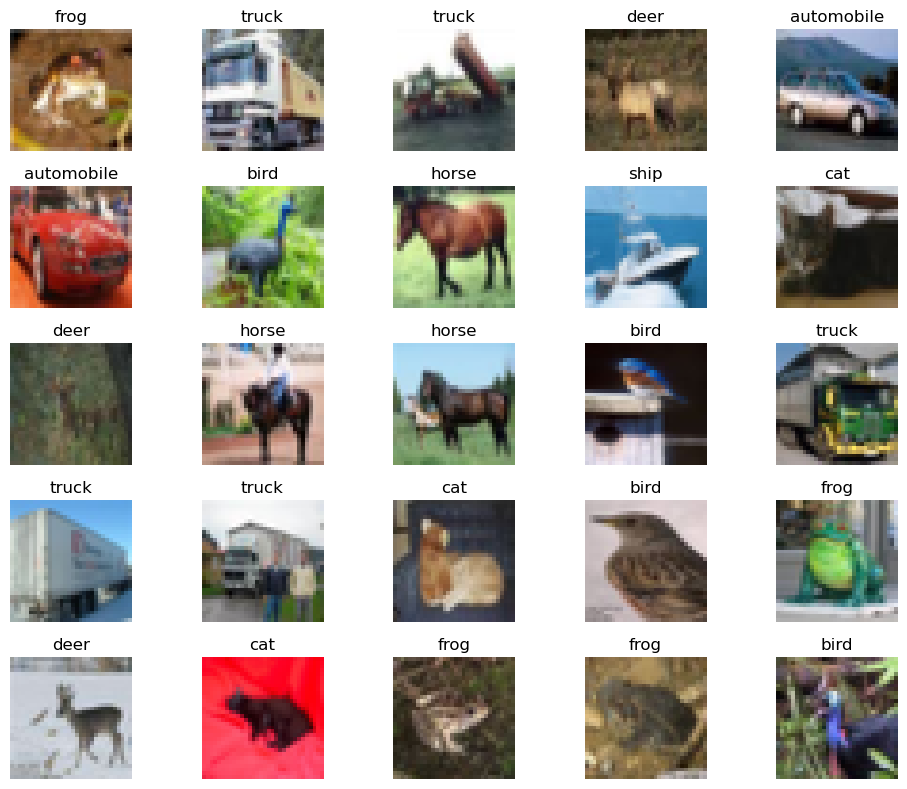

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)

    plt.imshow(x_train[i])

    plt.title(classes[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [71]:
encoder = LabelEncoder()
encoder.fit(y_train)
y_train = encoder.transform(y_train)
y_test = encoder.transform(y_test)

In [74]:
import tensorflow as tf
from keras import models, layers
model = tf.keras.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)), 

    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)